In [1]:
import pandas as pd
import sys
from pathlib import Path

PROJECT_ROOT = Path("../").resolve()

if str(PROJECT_ROOT) not in sys.path:
    sys.path.append(str(PROJECT_ROOT))

import pandas as pd
import warnings
warnings.filterwarnings("ignore")

from src.data_loader import DataLoader
from src.preprocessing import TimeSeriesPreprocessor
from src.backtesting import Backtester
from src.visualization import PortfolioVisualizer

In [2]:
assets = {
    "TSLA": "../data/processed/TSLA_processed.csv",
    "SPY": "../data/processed/SPY_processed.csv",
    "BND": "../data/processed/BND_processed.csv"
}

preprocessor = TimeSeriesPreprocessor()

returns = pd.DataFrame()

for asset, path in assets.items():

    loader = DataLoader(path)
    df = loader.load_data()

    df = preprocessor.clean_data(df)

    returns[asset] = df["Daily_Return"]

returns = returns.dropna()

returns.head()

,TSLA,SPY,BND
0,-0.042041,-0.018060,0.002904
1,-0.042041,-0.018060,0.002904
2,0.005664,-0.009419,0.002895
3,-0.001562,0.012461,0.000602
4,-0.001564,0.017745,-0.001563


In [3]:
weights_df = pd.read_csv("../outputs/optimal_portfolio.csv")
optimal_weights = dict(zip(weights_df["Asset"], weights_df["Weight"]))

In [4]:
backtester = Backtester(
    returns=returns,
    portfolio_weights=optimal_weights
)

In [5]:
backtest_data = backtester.prepare_backtest_data(periods=252)

backtest_data.head()

,TSLA,SPY,BND
2636,-0.006600,0.004968,-0.002313
2637,-0.018447,0.004781,0.003954
2638,-0.053359,-0.000324,-0.003939
2639,0.049682,0.004533,-0.001091
2640,-0.000950,0.007881,-0.002457


In [6]:
strategy = backtester.strategy_returns(backtest_data)
benchmark = backtester.benchmark_returns(backtest_data)

In [7]:
summary = backtester.performance_summary(strategy, benchmark)
summary

,Metric,Strategy,Benchmark
0,Total Return,0.211042,0.124914
1,Annualized Return,0.211042,0.124914
2,Annualized Volatility,0.125317,0.081184
3,Sharpe Ratio,1.524463,1.292304
4,Maximum Drawdown,-0.091331,-0.061056


In [8]:
backtester.save_results(
    summary,
    "../outputs/performance_metrics.csv"
)

Saved: ..\outputs\performance_metrics.csv


In [9]:
viz = PortfolioVisualizer()

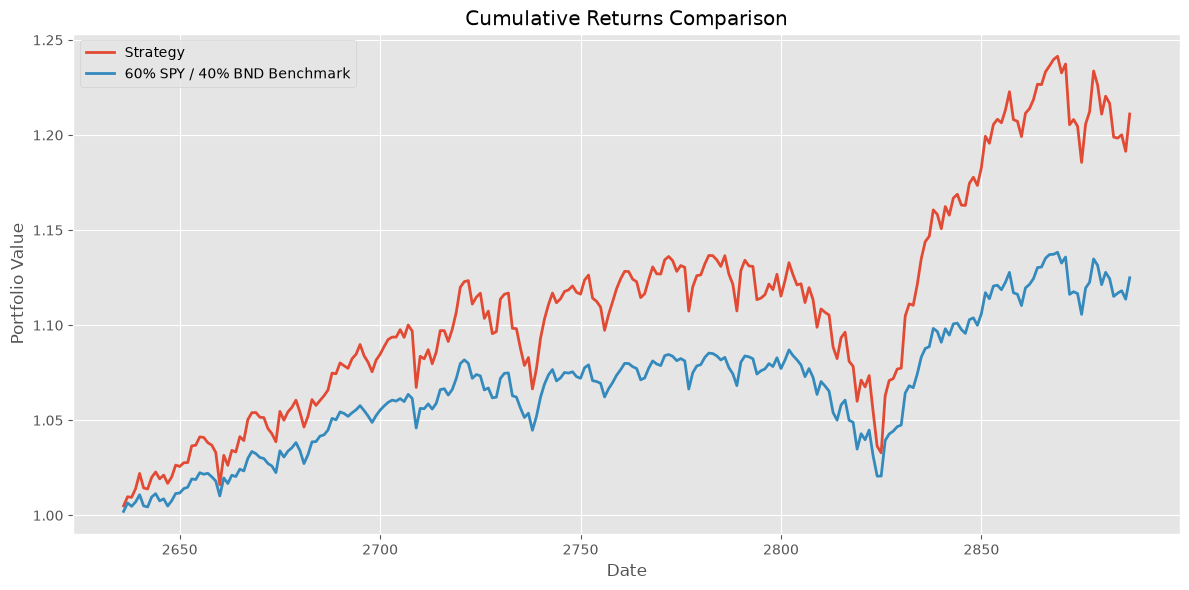

In [10]:
viz.cumulative_returns_plot(
    strategy,
    benchmark,
    "../figures/cumulative_returns.png"
)

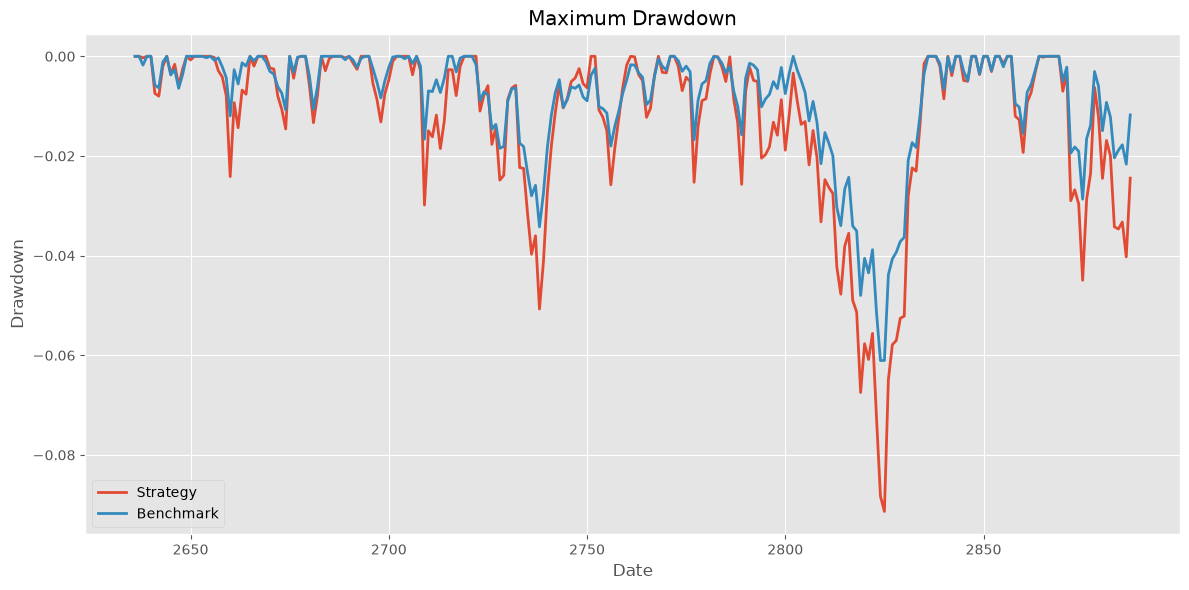

In [11]:
viz.drawdown_plot(
    strategy,
    benchmark,
    "../figures/drawdown.png"
)